# **Austria GP 2025**
## Tyre and Stint Analysis


In [1]:
# Imports
import sys
import importlib
sys.path.append("../..")

import Sliplib.slipload as sl
import Sliplib.selection as slipclassify
import Sliplib.GridSum as grid_sum
import Sliplib.plotting as slplot

importlib.reload(slipclassify)
importlib.reload(grid_sum)

<module 'Sliplib.GridSum' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Austria_GP/notebooks/../../Sliplib/GridSum.py'>

In [2]:
# Load Race Session
R_session = sl.load_gp(2025,"Austrian Grand Prix","R")
R_session.load()

core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '16', '44', '63', '30', '14', '5', '27', '31', '87', '6', '10', 

### Load Lap Data

In [3]:
# Extract Lap Data
R_Laps = R_session.laps
R_Laps.head(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:12:37.412000,NOR,4,0 days 00:01:28.861000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.326000,...,True,McLaren,0 days 01:11:08.287000,2025-06-29 13:18:01.080,124,1.0,False,,False,False
1,0 days 01:14:31.838000,NOR,4,0 days 00:01:54.426000,2.0,1.0,NaT,NaT,0 days 00:00:26.438000,0 days 00:00:53.661000,...,True,McLaren,0 days 01:12:37.412000,2025-06-29 13:19:30.205,4,1.0,False,,False,False
2,0 days 01:16:24.860000,NOR,4,0 days 00:01:53.022000,3.0,1.0,NaT,NaT,0 days 00:00:26.434000,0 days 00:00:50.148000,...,True,McLaren,0 days 01:14:31.838000,2025-06-29 13:21:24.631,41,1.0,False,,False,False
3,0 days 01:17:35.114000,NOR,4,0 days 00:01:10.254000,4.0,1.0,NaT,NaT,0 days 00:00:17.564000,0 days 00:00:31.393000,...,True,McLaren,0 days 01:16:24.860000,2025-06-29 13:23:17.653,1,1.0,False,,False,True
4,0 days 01:18:44.972000,NOR,4,0 days 00:01:09.858000,5.0,1.0,NaT,NaT,0 days 00:00:17.488000,0 days 00:00:31.430000,...,True,McLaren,0 days 01:17:35.114000,2025-06-29 13:24:27.907,1,1.0,False,,False,True


### Stint Overview
Get the Stint breakdown (compound, laps run, freshness) for the entire grid

In [4]:
# Get the Stint of all drivers
grid_stint = grid_sum.get_stint(R_Laps)
grid_stint

,Driver,Total Stint,Pit Stops
0,ANT,1,0
1,VER,1,0
2,ALO,2,1
3,LAW,2,1
4,ALB,2,1
5,HAM,3,2
6,NOR,3,2
7,PIA,3,2
8,HUL,3,2
9,OCO,3,2


In [5]:
# Extract Data
grid_stint.to_csv("../data/Race_Stint_Summary.csv",index=False)

### Insights
- *(Fill in after reviewing grid_stint: who ran a 1-stop vs 2-stop? Any outlier strategies?)*

## Driver Tyre Analysis
From the Result and Lap Analysis notebook, the drivers under focus are:
- Nico Hulkenberg
- Esteban Ocon
- Lando Norris
- Oscar Piastri
- Charles Leclerc
- Lewis Hamilton

In [6]:
# Import Drivers
hul,oco,nor,pia,lec,ham = slipclassify.pick_athletes(R_Laps,["HUL","OCO","NOR","PIA","LEC","HAM"])

# Test
lec.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
140,0 days 01:12:42.753000,LEC,16,0 days 00:01:34.202000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.122000,...,True,Ferrari,0 days 01:11:08.287000,2025-06-29 13:18:01.080,124,3.0,False,,False,False
141,0 days 01:14:34.285000,LEC,16,0 days 00:01:51.532000,2.0,1.0,NaT,NaT,0 days 00:00:24.098000,0 days 00:00:53.387000,...,True,Ferrari,0 days 01:12:42.753000,2025-06-29 13:19:35.546,4,3.0,False,,False,False
142,0 days 01:16:25.878000,LEC,16,0 days 00:01:51.593000,3.0,1.0,NaT,NaT,0 days 00:00:26.530000,0 days 00:00:50.544000,...,True,Ferrari,0 days 01:14:34.285000,2025-06-29 13:21:27.078,41,3.0,False,,False,False
143,0 days 01:17:36.813000,LEC,16,0 days 00:01:10.935000,4.0,1.0,NaT,NaT,0 days 00:00:17.722000,0 days 00:00:31.653000,...,True,Ferrari,0 days 01:16:25.878000,2025-06-29 13:23:18.671,1,3.0,False,,False,True
144,0 days 01:18:47.040000,LEC,16,0 days 00:01:10.227000,5.0,1.0,NaT,NaT,0 days 00:00:17.387000,0 days 00:00:31.363000,...,True,Ferrari,0 days 01:17:36.813000,2025-06-29 13:24:29.606,1,3.0,False,,False,True
145,0 days 01:19:57.250000,LEC,16,0 days 00:01:10.210000,6.0,1.0,NaT,NaT,0 days 00:00:17.441000,0 days 00:00:31.437000,...,True,Ferrari,0 days 01:18:47.040000,2025-06-29 13:25:39.833,1,3.0,False,,False,True
146,0 days 01:21:07.443000,LEC,16,0 days 00:01:10.193000,7.0,1.0,NaT,NaT,0 days 00:00:17.446000,0 days 00:00:31.384000,...,True,Ferrari,0 days 01:19:57.250000,2025-06-29 13:26:50.043,1,3.0,False,,False,True
147,0 days 01:22:17.355000,LEC,16,0 days 00:01:09.912000,8.0,1.0,NaT,NaT,0 days 00:00:17.448000,0 days 00:00:31.269000,...,True,Ferrari,0 days 01:21:07.443000,2025-06-29 13:28:00.236,1,3.0,False,,False,True
148,0 days 01:23:27.478000,LEC,16,0 days 00:01:10.123000,9.0,1.0,NaT,NaT,0 days 00:00:17.561000,0 days 00:00:31.283000,...,True,Ferrari,0 days 01:22:17.355000,2025-06-29 13:29:10.148,1,3.0,False,,False,True
149,0 days 01:24:37.547000,LEC,16,0 days 00:01:10.069000,10.0,1.0,NaT,NaT,0 days 00:00:17.714000,0 days 00:00:31.092000,...,True,Ferrari,0 days 01:23:27.478000,2025-06-29 13:30:20.271,1,3.0,False,,False,True


### Tyre Data per Driver

In [7]:
# Get Tyre Data for each driver
hul_tyre,oco_tyre,nor_tyre,pia_tyre,lec_tyre,ham_tyre = [
    slipclassify.pick_tyre_data(drv) for drv in [hul,oco,nor,pia,lec,ham]
]

# Test
oco_tyre.head(5)

,Driver,LapNumber,Compound,TyreLife,FreshTyre,Stint
627,OCO,1.0,MEDIUM,1.0,True,1.0
628,OCO,2.0,MEDIUM,2.0,True,1.0
629,OCO,3.0,MEDIUM,3.0,True,1.0
630,OCO,4.0,MEDIUM,4.0,True,1.0
631,OCO,5.0,MEDIUM,5.0,True,1.0


### Stint Breakdown (Compound, Lap Range, Freshness)

In [8]:
# HUL vs OCO Stint Breakdown
hul_tyre.groupby("Stint").agg({
    "LapNumber": ["min","max"],
    "Compound": "first",
    "FreshTyre": "first"
})

LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  12.0     SOFT      True
2.0        13.0  42.0   MEDIUM      True
3.0        43.0  69.0   MEDIUM      True

In [9]:
oco_tyre.groupby("Stint").agg({
    "LapNumber": ["min","max"],
    "Compound": "first",
    "FreshTyre": "first"
})

LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  19.0   MEDIUM      True
2.0        20.0  50.0     HARD      True
3.0        51.0  69.0     HARD      True

#### Top 4 Stint Breakdown

In [10]:
# Top 4 Stint Breakdown
for name, tyre_df in zip(["NOR","PIA","LEC","HAM"], [nor_tyre,pia_tyre,lec_tyre,ham_tyre]):
    print(f"--- {name} ---")
    display(tyre_df.groupby("Stint").agg({
        "LapNumber": ["min","max"],
        "Compound": "first",
        "FreshTyre": "first"
    }))

--- NOR ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  20.0   MEDIUM      True
2.0        21.0  52.0     HARD      True
3.0        53.0  70.0   MEDIUM      True

--- PIA ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  24.0   MEDIUM      True
2.0        25.0  53.0     HARD      True
3.0        54.0  70.0   MEDIUM      True

--- LEC ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  25.0   MEDIUM      True
2.0        26.0  49.0     HARD      True
3.0        50.0  70.0   MEDIUM      True

--- HAM ---


LapNumber       Compound FreshTyre
            min   max    first     first
Stint                                   
1.0         1.0  26.0   MEDIUM      True
2.0        27.0  50.0     HARD      True
3.0        51.0  70.0   MEDIUM      True

### Insights
- *(Fill in: who pitted early/late, undercut vs overcut attempts, compound choices)*

## Tyre Degradation
This part has 2 plots:
- One for the 2 Contenders
- Other for the Top 4

### HUL vs OCO

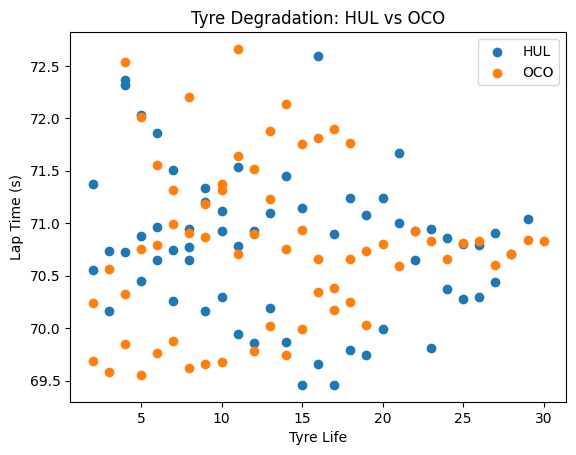

In [11]:
# Measure Tyre Degradation - HUL vs OCO
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for name, drv in zip(["HUL","OCO"], [hul,oco]):
    clean = drv.pick_quicklaps()
    ax.scatter(clean["TyreLife"], clean["LapTime"].dt.total_seconds(), label=name)

ax.set_xlabel("Tyre Life")
ax.set_ylabel("Lap Time (s)")
ax.set_title("Tyre Degradation: HUL vs OCO")
ax.legend()
plt.show()

Pretty much a straightforward comparison of tyre wear pace between the 2 Contenders.

#### Top 4 Plot

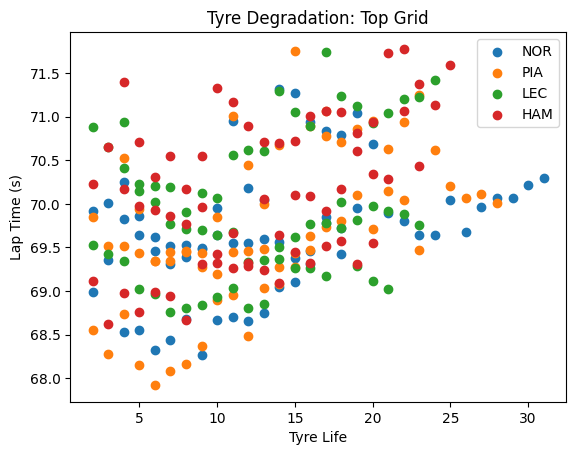

In [12]:
# Measure Tyre Degradation - Top 4
fig, ax = plt.subplots()
for name, drv in zip(["NOR","PIA","LEC","HAM"], [nor,pia,lec,ham]):
    clean = drv.pick_quicklaps()
    ax.scatter(clean["TyreLife"], clean["LapTime"].dt.total_seconds(), label=name)

ax.set_xlabel("Tyre Life")
ax.set_ylabel("Lap Time (s)")
ax.set_title("Tyre Degradation: Top Grid")
ax.legend()
plt.show()

From the above graph! *(Fill in: whose tyres held up best over stint length?)*

### Insights
- No Red Flag affecting tyre strategy during these stints
- *(Fill in further conclusions on degradation slope per driver)*